In [1]:
# Run the setup
%run startup.py

# Import classes used to help easily run tests using pybatfish
from verificationPythonSupport import LocationPropertyPair,VerificationQuery,Clause

# Help functions to run tests and examples easier
def create(networkName:str,snapshotName:str,snapshotPath:str):
    bf = Session(host="localhost")
    bf.set_network(networkName)
    bf.init_snapshot(snapshotPath, name=snapshotName, overwrite=True)
    return bf

# This function is what includes the call to the pybatfish verification question
def runVerificationQuestion(bf,query:VerificationQuery):
    formatted = query.format()
    # result = bf.q.verify(formatted)
    if formatted["assumption_locations"] == "":
        result = bf.q.verify(
            target=formatted["target"],
            location=formatted["location"],
            readable=True).answer()
    else:
        result = bf.q.verify(
            target=formatted["target"],
            location=formatted["location"],
            assumption_locations=formatted["assumption_locations"],
            assumptions=formatted["assumptions"],
            readable=True).answer()
    return result.frame()

def runAndDisplay(networkName:str,snapshotName:str,snapshotPath:str,query:VerificationQuery):
    bf = create(networkName,snapshotName,snapshotPath)
    verificationResult = runVerificationQuestion(bf,query)
    show(verificationResult)


## Example One
This example is a simple three-node network which is shown below. The property that we want to verify is that no traffic going from the `Border3` node (ip address of `10.0.0.3`) to the outside of the network (to `100.0.0.2`) has the prefix `25.13.0.0/16`. The goal is to do this by using the community `10:10` to tag this traffic coming from the node `100.0.0.1`. 

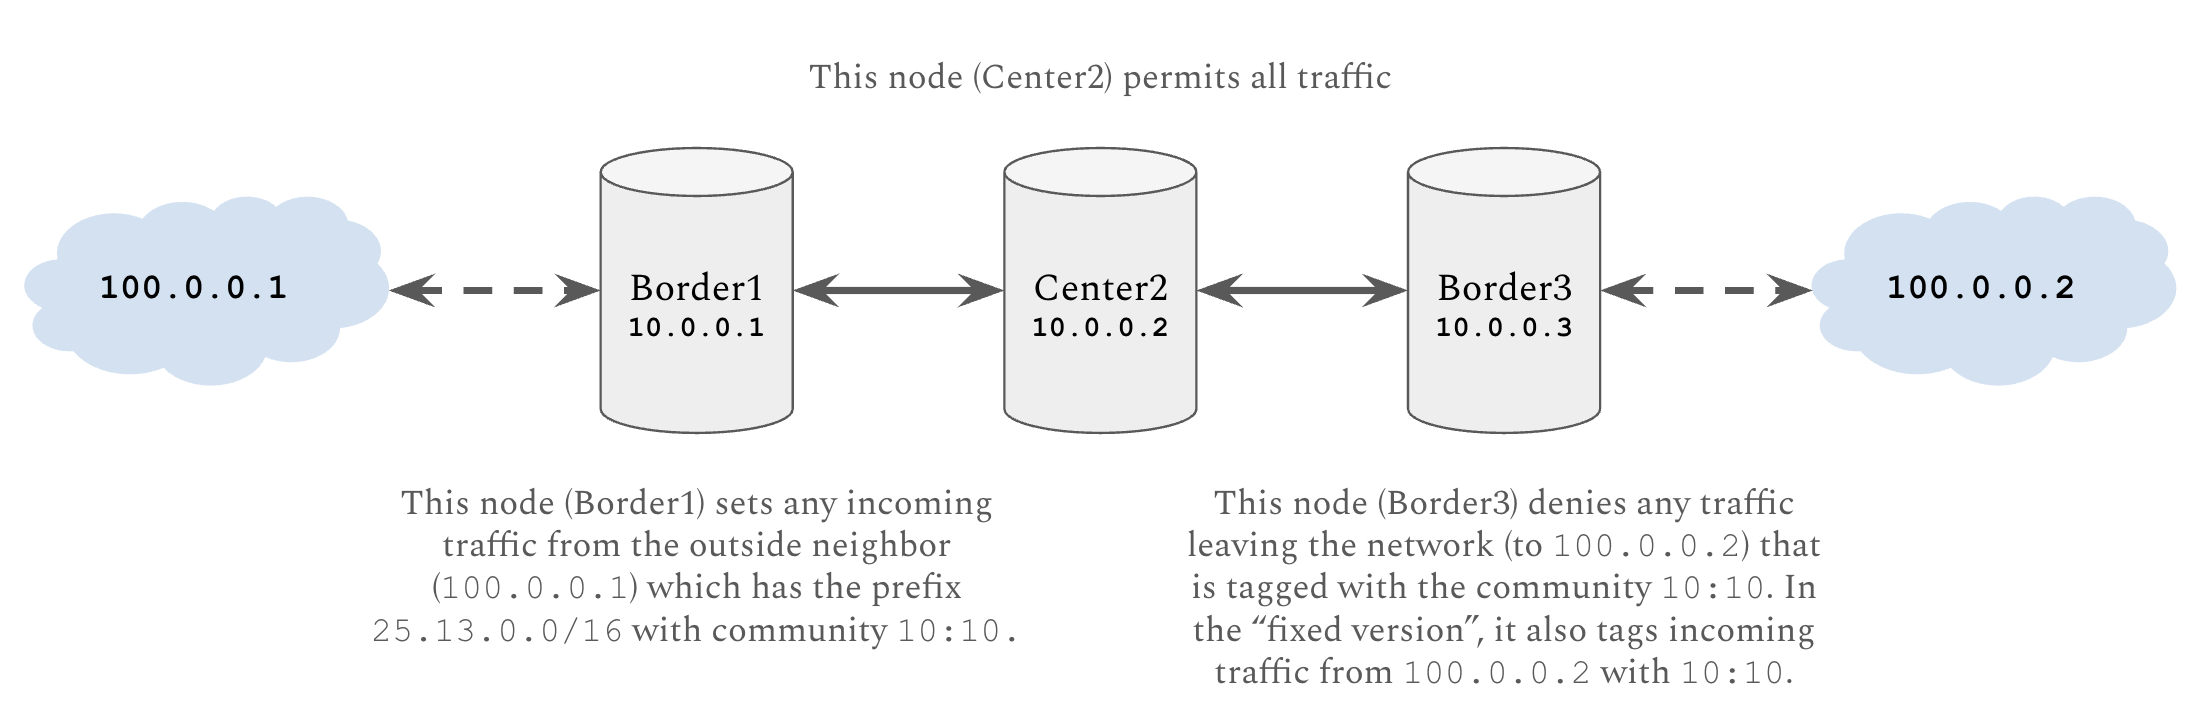

In [2]:
networkName = "exampleOne_network"
snapshotName = "exampleOne_snapshot"
snapshotPath = "snapshots/exampleOne"
target = LocationPropertyPair(location="10.0.0.3 -> 100.0.0.2",property=[Clause(communities=[],prefixes=["!25.13.0.0/16"])])
query = VerificationQuery(target=target,assumptions=[])
runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Assumption_Location,Assumption,Overall_Verification_Result,Assumption_Verification_Result,Inferred_Property
0,100.0.0.1 -> 10.0.0.1,true,False,True,true
1,100.0.0.2 -> 10.0.0.3,true,False,False,has comm ^10:10$ OR does not have prefix 25.13.0.0/16


The previous examples failed overall verification because even though the input edge from the ip address `100.0.0.1` infers the invariant true (implying an incoming traffic is ok), on the other end, we need to make sure that the prefix we are trying to avoid (`25.13.0.0/16`) doesn't come from the other outside incoming edge (`100.0.0.2 -> 10.0.0.3`). 

This assumption makes sense if we want to prove that routes with this prefix don't come out to the node `100.0.0.2`, then we would assume it wouldn't send those routes back into the network. This is updated in the following section by adding that any traffic coming in on the edge `10.0.0.3` from `100.0.0.2` does not have the prefix `25.13.0.0/16`. Alternatively, we can state that this traffic should be assumed to have a conflicting prefix (this is commented out).

_**NOTE:**_ if you swap comments and run the code with the asssumption that traffic over the edge `100.0.0.2 -> 10.0.0.3` has the prefix `13.25.0.0/16`, the verification will accurately succeed. But, due to a limitation of the weak invaraint display that is currently used, this assumption will not correctly be reported.

In [3]:
networkName = "exampleOne_network"
snapshotName = "exampleOne_snapshot"
snapshotPath = "snapshots/exampleOne"
target = LocationPropertyPair(location="10.0.0.3 -> 100.0.0.2",property=[Clause(communities=[],prefixes=["!25.13.0.0/16"])])
assumption = LocationPropertyPair(location="100.0.0.2 -> 10.0.0.3",property=[Clause(communities=[],prefixes=["!25.13.0.0/16"])])
#assumption = LocationPropertyPair(location="100.0.0.2 -> 10.0.0.3",property=[Clause(communities=[],prefixes=["13.25.0.0/16"])])
query = VerificationQuery(target=target,assumptions=[assumption])
runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Assumption_Location,Assumption,Overall_Verification_Result,Assumption_Verification_Result,Inferred_Property
0,100.0.0.1 -> 10.0.0.1,true,True,True,true
1,100.0.0.2 -> 10.0.0.3,does not have prefix 25.13.0.0/16,True,True,has comm ^10:10$ OR does not have prefix 25.13.0.0/16


Another way to fix this network is to say that any incoming traffic (to the node `10.0.0.3`) from the outside nodes (in this example that is `100.0.0.2`) is also tagged with the community. This would ensure that the traffic is not sent back to the outside node it was received from. This is shown in the example below. This is likely a better fix than the previous one because it makes no assumptions about traffic coming into the network.

In [4]:
networkName = "exampleOne_fixed_network"
snapshotName = "exampleOne_fixed_snapshot"
snapshotPath = "snapshots/exampleOneFixed"
target = LocationPropertyPair(location="10.0.0.3 -> 100.0.0.2",property=[Clause(communities=[],prefixes=["!25.13.0.0/16"])])
query = VerificationQuery(target=target,assumptions=[])
runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Assumption_Location,Assumption,Overall_Verification_Result,Assumption_Verification_Result,Inferred_Property
0,100.0.0.1 -> 10.0.0.1,true,True,True,true
1,100.0.0.2 -> 10.0.0.3,true,True,True,true


## Example Two


In [5]:
networkName = "exampleTwo_network"
snapshotName = "exampleTwo_snapshot"
snapshotPath = "snapshots/exampleTwo"
target = LocationPropertyPair(location="10.0.0.4 -> 100.0.0.4",property=[Clause(communities=["100:1","100:2"],prefixes=[])])
query = VerificationQuery(target=target,assumptions=[])
runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Assumption_Location,Assumption,Overall_Verification_Result,Assumption_Verification_Result,Inferred_Property
0,100.0.0.1 -> 10.0.0.1,true,False,False,has comm ^100:2$ OR does not have comm ^100:3$
1,100.0.0.2 -> 10.0.0.2,true,False,False,has comm ^100:1$ OR does not have comm ^100:3$
2,100.0.0.4 -> 10.0.0.4,true,False,False,does not have comm ^100:3$ OR has comm ^100:1$ and has comm ^100:2$


In [6]:
networkName = "exampleTwo_better_network"
snapshotName = "exampleTwo_better_snapshot"
snapshotPath = "snapshots/exampleTwoBetter"
target = LocationPropertyPair(location="10.0.0.4 -> 100.0.0.4",property=[Clause(communities=["100:1","100:2"],prefixes=[])])
query = VerificationQuery(target=target,assumptions=[])
runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Assumption_Location,Assumption,Overall_Verification_Result,Assumption_Verification_Result,Inferred_Property
0,100.0.0.1 -> 10.0.0.1,true,False,True,true
1,100.0.0.2 -> 10.0.0.2,true,False,True,true
2,100.0.0.4 -> 10.0.0.4,true,False,False,does not have comm ^100:3$ OR has comm ^100:1$ and has comm ^100:2$


In [7]:
networkName = "exampleTwo_better_network"
snapshotName = "exampleTwo_better_snapshot"
snapshotPath = "snapshots/exampleTwoBetter"
target = LocationPropertyPair(location="10.0.0.4 -> 100.0.0.4",property=[Clause(communities=["100:1","100:2"],prefixes=[])])
assumption = LocationPropertyPair(location="100.0.0.4 -> 10.0.0.4",property=[Clause(communities=["!100:3"],prefixes=[])])
query = VerificationQuery(target=target,assumptions=[assumption])
runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Assumption_Location,Assumption,Overall_Verification_Result,Assumption_Verification_Result,Inferred_Property
0,100.0.0.1 -> 10.0.0.1,true,True,True,true
1,100.0.0.2 -> 10.0.0.2,true,True,True,true
2,100.0.0.4 -> 10.0.0.4,does not have comm ^100:3$,True,True,does not have comm ^100:3$ OR has comm ^100:1$ and has comm ^100:2$


In [8]:
networkName = "exampleTwo_fixed_network"
snapshotName = "exampleTwo_fixed_snapshot"
snapshotPath = "snapshots/exampleTwoFixed"
target = LocationPropertyPair(location="10.0.0.4 -> 100.0.0.4",property=[Clause(communities=["100:1","100:2"],prefixes=[])])
query = VerificationQuery(target=target,assumptions=[])
runAndDisplay(networkName,snapshotName,snapshotPath,query)

,Assumption_Location,Assumption,Overall_Verification_Result,Assumption_Verification_Result,Inferred_Property
0,100.0.0.1 -> 10.0.0.1,true,True,True,true
1,100.0.0.2 -> 10.0.0.2,true,True,True,true
2,100.0.0.4 -> 10.0.0.4,true,True,True,true
